<a href="https://colab.research.google.com/github/lemwaizz/formative2_G35/blob/main/Formative_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Loading Data

In [178]:
from google.colab import drive
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Mount Google Drive
drive.mount('/content/drive')

# Set path to the data folders
BASE_PATH = '/content/drive/MyDrive/hmm/'
MWAI_PATH = os.path.join(BASE_PATH, 'mwai_data')
WENGS_PATH = os.path.join(BASE_PATH, 'wengel_data')

print(f"\nData directories:")
print(f"  Dennis: {MWAI_PATH}")
print(f"  Wengel: {WENGS_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Data directories:
  Dennis: /content/drive/MyDrive/hmm/mwai_data
  Wengel: /content/drive/MyDrive/hmm/wengel_data


## Data Merging

In [179]:
# Load accelerometer and gyroscope data from a single recording folder, which will return merged dataframe with both sensors synchronized.
def load_single_recording(recording_path):
    try:
        acc_path = os.path.join(recording_path, 'Accelerometer.csv')
        gyro_path = os.path.join(recording_path, 'Gyroscope.csv')

        if not os.path.exists(acc_path) or not os.path.exists(gyro_path):
            print(f"    Missing Accelerometer.csv or Gyroscope.csv in {recording_path}")
            return None

        acc_df = pd.read_csv(acc_path)
        gyro_df = pd.read_csv(gyro_path)

        if acc_df.empty or gyro_df.empty:
            print(f"    Accelerometer.csv or Gyroscope.csv is empty in {recording_path}")
            return None

        # Handle different time column formats
        if 'seconds_elapsed' not in acc_df.columns and 'time' in acc_df.columns:
            acc_df['seconds_elapsed'] = (acc_df['time'] - acc_df['time'].iloc[0]) / 1e9
        if 'seconds_elapsed' not in gyro_df.columns and 'time' in gyro_df.columns:
            gyro_df['seconds_elapsed'] = (gyro_df['time'] - gyro_df['time'].iloc[0]) / 1e9

        # Ensure 'seconds_elapsed' exists for merging
        if 'seconds_elapsed' not in acc_df.columns or 'seconds_elapsed' not in gyro_df.columns:
            print(f"    Missing 'seconds_elapsed' column after processing time for {recording_path}")
            return None

        # Rename columns for clarity
        acc_df = acc_df.rename(columns = {'x': 'x_acc', 'y': 'y_acc', 'z': 'z_acc'})
        gyro_df = gyro_df.rename(columns = {'x': 'x_gyro', 'y': 'y_gyro', 'z': 'z_gyro'})

        # Merge accelerometer and gyroscope data
        merged = pd.merge_asof(
            acc_df.sort_values('seconds_elapsed')[['seconds_elapsed', 'x_acc', 'y_acc', 'z_acc']],
            gyro_df.sort_values('seconds_elapsed')[['seconds_elapsed', 'x_gyro', 'y_gyro', 'z_gyro']],
            on='seconds_elapsed',
            direction='nearest'
        )
        print(f"    Successfully merged {len(merged)} samples from {recording_path}")
        return merged

    except Exception as e:
        print(f"    Error in load_single_recording for {recording_path}: {str(e)}")
        return None

# Load all recordings for a specific activity and participant
def load_activity_data(base_path, activity, participant_name):
    activity_path = os.path.join(base_path, activity)

    if not os.path.exists(activity_path):
        print(f"Activity folder not found: {activity_path}")
        return None

    all_recordings = []
    print(f"\nLoading {activity} for {participant_name}:")

    merged_data = load_single_recording(activity_path)

    if merged_data is not None and len(merged_data) > 0:
        merged_data['participant'] = participant_name
        merged_data['activity'] = activity
        merged_data['recording_id'] = f"{participant_name}_{activity}_recording_01"
        all_recordings.append(merged_data)
        print(f"  {activity} data appended: {len(merged_data)} samples")
    else:
        print(f"  No valid sensor data found directly in {activity_path} or merged data was empty.")

    if all_recordings:
        combined = pd.concat(all_recordings, ignore_index = True)
        print(f"Total: {len(combined)} samples from {len(all_recordings)} recordings for {activity}")
        return combined
    return None

## Loading Data from both participants

### Checking files in MWAI_PATH (Dennis's data)

In [180]:
print(f"Contents of {MWAI_PATH}:")
for item in os.listdir(MWAI_PATH):
    item_path = os.path.join(MWAI_PATH, item)
    if os.path.isdir(item_path):
        print(f"  Directory: {item}/")
        for sub_item in os.listdir(item_path):
            sub_item_path = os.path.join(item_path, sub_item)
            if os.path.isdir(sub_item_path):
                print(f"    Sub-directory: {sub_item}/")
                for file in os.listdir(sub_item_path):
                    print(f"      File: {file}")
            else:
                print(f"    File: {sub_item}")
    else:
        print(f"  File: {item}")


Contents of /content/drive/MyDrive/hmm/mwai_data:
  Directory: mwai_unextracted/
    File: Dennis_Standing_6-2026-03-02_12-32-25.zip
    File: Dennis_Standing_5-2026-03-02_12-31-25.zip
    File: Dennis_Standing_4-2026-03-02_12-30-42.zip
    File: Dennis_Standing_3-2026-03-02_12-29-47.zip
    File: Dennis_Standing_2_-2026-03-02_12-29-07.zip
    File: Dennis_Standing_1-2026-03-02_12-28-22.zip
    File: Dennis_Walking_6-2026-03-02_12-49-16.zip
    File: Dennis_Walking_5-2026-03-02_12-47-09.zip
    File: Dennis_Walking_4-2026-03-02_12-44-29.zip
    File: Dennis_Walking_3-2026-03-02_12-43-49.zip
    File: Dennis_Walking_1-2026-03-02_12-42-30.zip
    File: Dennis_Walking_2-2026-03-02_12-43-12.zip
    File: Dennis_Jumping_6-2026-03-02_13-01-24.zip
    File: Dennis_Jumping_4-2026-03-02_13-00-10.zip
    File: Dennis_Jumping_3-2026-03-02_12-59-30.zip
    File: Dennis_Jumping_2-2026-03-02_12-59-08.zip
    File: Dennis_Jumping_1-2026-03-02_12-58-35.zip
    File: Still_6-2026-03-02_13-12-23.zip
   

### Checking files in WENGS_PATH (Wengs's data)

In [181]:
print(f"Contents of {WENGS_PATH}:")
for item in os.listdir(WENGS_PATH):
    item_path = os.path.join(WENGS_PATH, item)
    if os.path.isdir(item_path):
        print(f"  Directory: {item}/")
        for sub_item in os.listdir(item_path):
            sub_item_path = os.path.join(item_path, sub_item)
            if os.path.isdir(sub_item_path):
                print(f"    Sub-directory: {sub_item}/")
                for file in os.listdir(sub_item_path):
                    print(f"      File: {file}")
            else:
                print(f"    File: {sub_item}")
    else:
        print(f"  File: {item}")


Contents of /content/drive/MyDrive/hmm/wengel_data:
  Directory: standing/
    File: GyroscopeUncalibrated.csv
    File: Gyroscope.csv
    File: Accelerometer.csv
    File: AccelerometerUncalibrated.csv
    File: Annotation.csv
    File: Metadata.csv
  Directory: jumping/
    File: Gyroscope.csv
    File: Annotation.csv
    File: GyroscopeUncalibrated.csv
    File: Metadata.csv
    File: Accelerometer.csv
    File: AccelerometerUncalibrated.csv
  Directory: walking/
    File: GyroscopeUncalibrated.csv
    File: Annotation.csv
    File: AccelerometerUncalibrated.csv
    File: Metadata.csv
    File: Gyroscope.csv
    File: Accelerometer.csv
  Directory: wengs_unextracted/
    File: w_standing_4-2026-03-02_12-34-46.zip
    File: w_standing_3_-2026-03-02_12-34-14.zip
    File: w_standing_2_-2026-03-02_12-33-52.zip
    File: w_standing_1-2026-03-02_12-33-26.zip
    File: w_standing_6_-2026-03-02_12-38-12.zip
    File: w_standing_5_-2026-03-02_12-37-21.zip
    File: w_walking_6_-2026-03-02_1

In [182]:
activities = ['walking', 'standing', 'jumping', 'still']
all_data = []

# Load Dennis' data
print("\nDennis' Data:")
for activity in activities:
    data = load_activity_data(MWAI_PATH, activity, 'Dennis')
    if data is not None:
        all_data.append(data)

# Load Wengs' data
print("\nWengs' Data:")
for activity in activities:
    data = load_activity_data(WENGS_PATH, activity, 'Wengs')
    if data is not None:
        all_data.append(data)

# Combine all data
complete_dataset = pd.concat(all_data, ignore_index = True)

print(f"\nTotal samples collected: {len(complete_dataset):,}")
print(f"\nSamples per activity:")
for activity, count in complete_dataset.groupby('activity').size().items():
    print(f"  {activity.capitalize():<12}: {count:>6,} samples")
print(f"\nTotal recordings: {complete_dataset['recording_id'].nunique()}")


Dennis' Data:

Loading walking for Dennis:
    Successfully merged 1096 samples from /content/drive/MyDrive/hmm/mwai_data/walking
  walking data appended: 1096 samples
Total: 1096 samples from 1 recordings for walking

Loading standing for Dennis:
    Successfully merged 1071 samples from /content/drive/MyDrive/hmm/mwai_data/standing
  standing data appended: 1071 samples
Total: 1071 samples from 1 recordings for standing

Loading jumping for Dennis:
    Successfully merged 1095 samples from /content/drive/MyDrive/hmm/mwai_data/jumping
  jumping data appended: 1095 samples
Total: 1095 samples from 1 recordings for jumping

Loading still for Dennis:
    Successfully merged 1107 samples from /content/drive/MyDrive/hmm/mwai_data/still
  still data appended: 1107 samples
Total: 1107 samples from 1 recordings for still

Wengs' Data:

Loading walking for Wengs:
    Successfully merged 1071 samples from /content/drive/MyDrive/hmm/wengel_data/walking
  walking data appended: 1071 samples
Tota

## Exploratory Data Analysis

In [183]:
#checking dataset shape
print("Dataset shape:", complete_dataset.shape)

print("\nColumns:")
print(complete_dataset.columns)

print("\nFirst rows:")
display(complete_dataset.head())

print("\nActivities:")
print(complete_dataset['activity'].unique())

Dataset shape: (8697, 10)

Columns:
Index(['seconds_elapsed', 'x_acc', 'y_acc', 'z_acc', 'x_gyro', 'y_gyro',
       'z_gyro', 'participant', 'activity', 'recording_id'],
      dtype='object')

First rows:


,seconds_elapsed,x_acc,y_acc,z_acc,x_gyro,y_gyro,z_gyro,participant,activity,recording_id
0,0.089064,0.640589,-0.204133,-0.044842,0.115249,-0.038500,-0.107685,Dennis,walking,Dennis_walking_recording_01
1,0.099083,0.579399,-0.150883,0.022771,0.081937,-0.037269,-0.109225,Dennis,walking,Dennis_walking_recording_01
2,0.109101,0.551807,-0.167039,0.003397,0.046818,-0.036487,-0.128054,Dennis,walking,Dennis_walking_recording_01
3,0.119117,0.564239,-0.203704,-0.062886,0.014427,-0.046408,-0.148270,Dennis,walking,Dennis_walking_recording_01
4,0.129135,0.542789,-0.216673,-0.196932,-0.002133,-0.049153,-0.163235,Dennis,walking,Dennis_walking_recording_01



Activities:
['walking' 'standing' 'jumping' 'still']


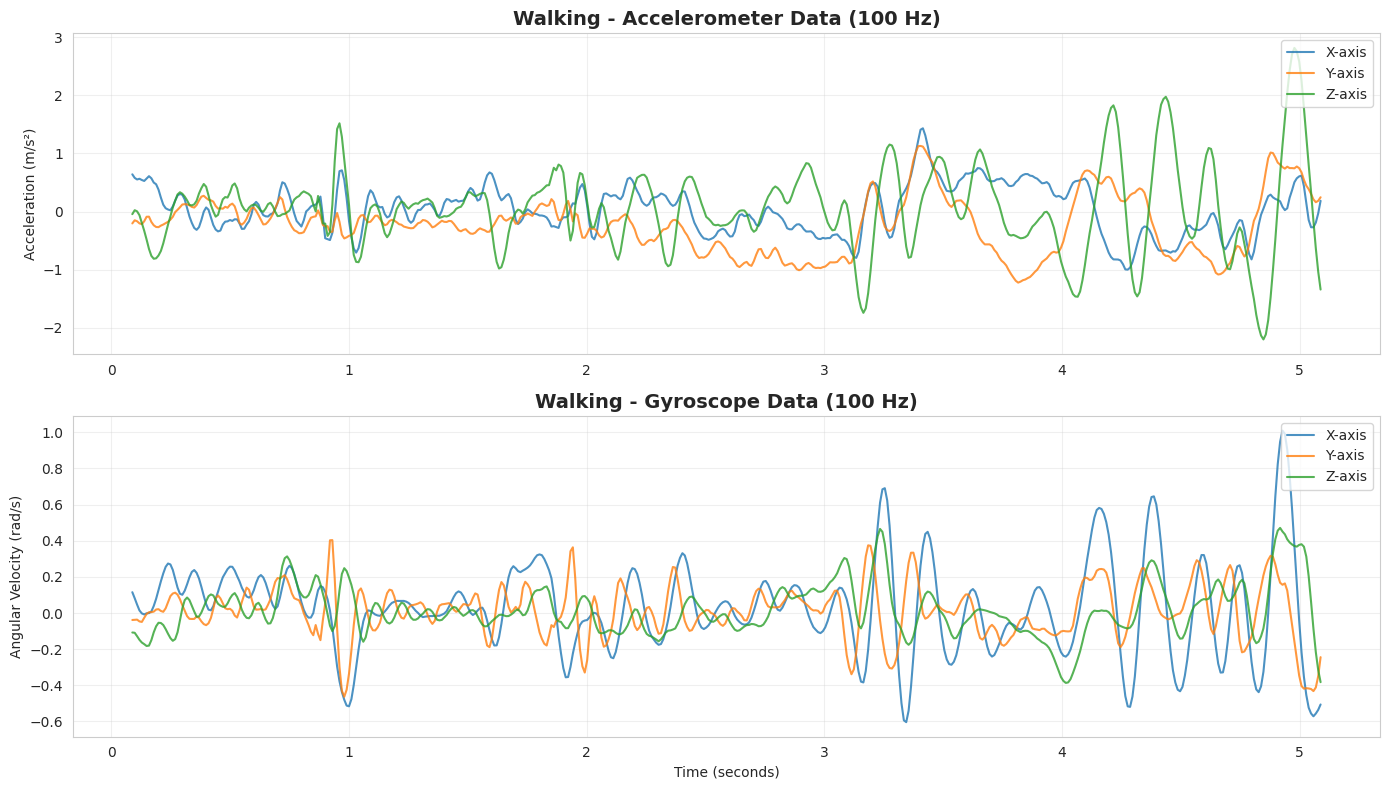

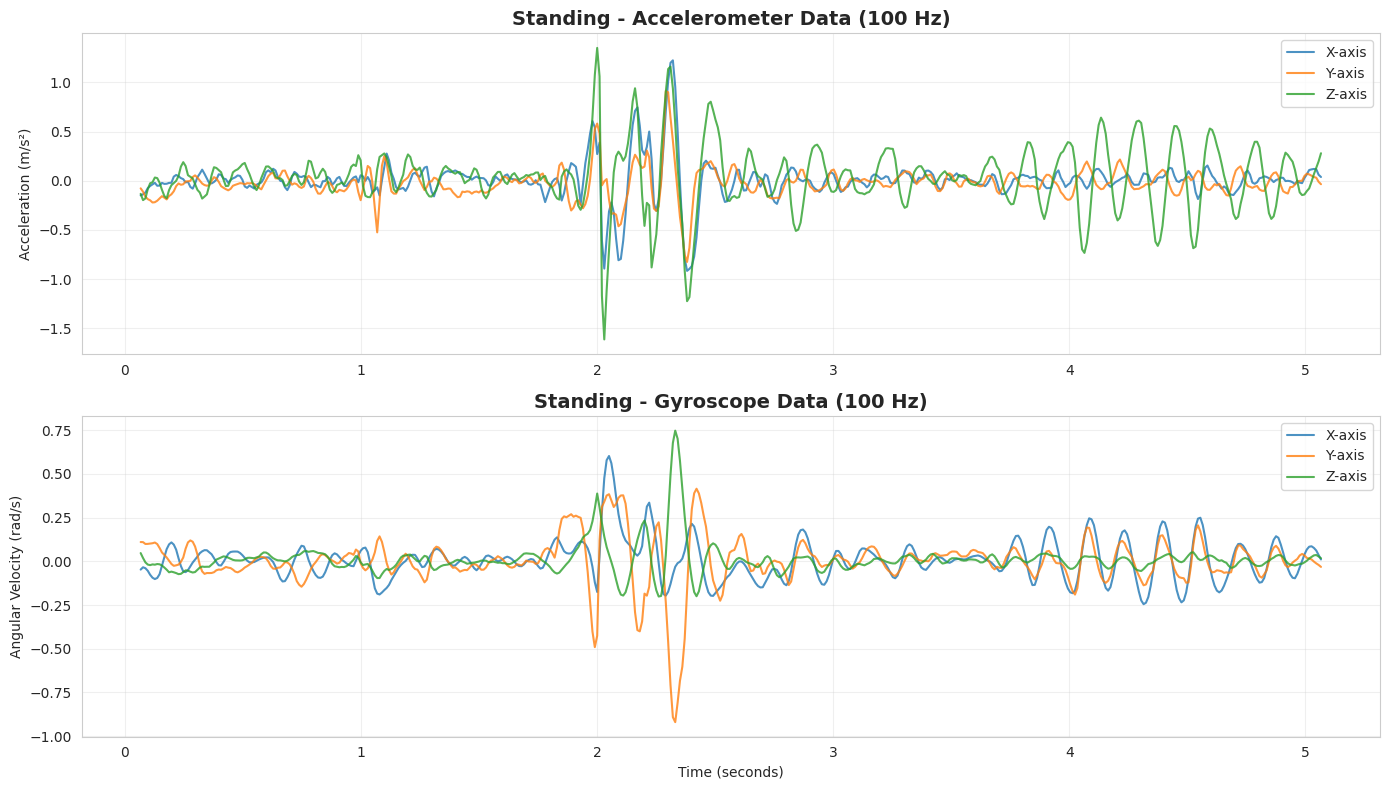

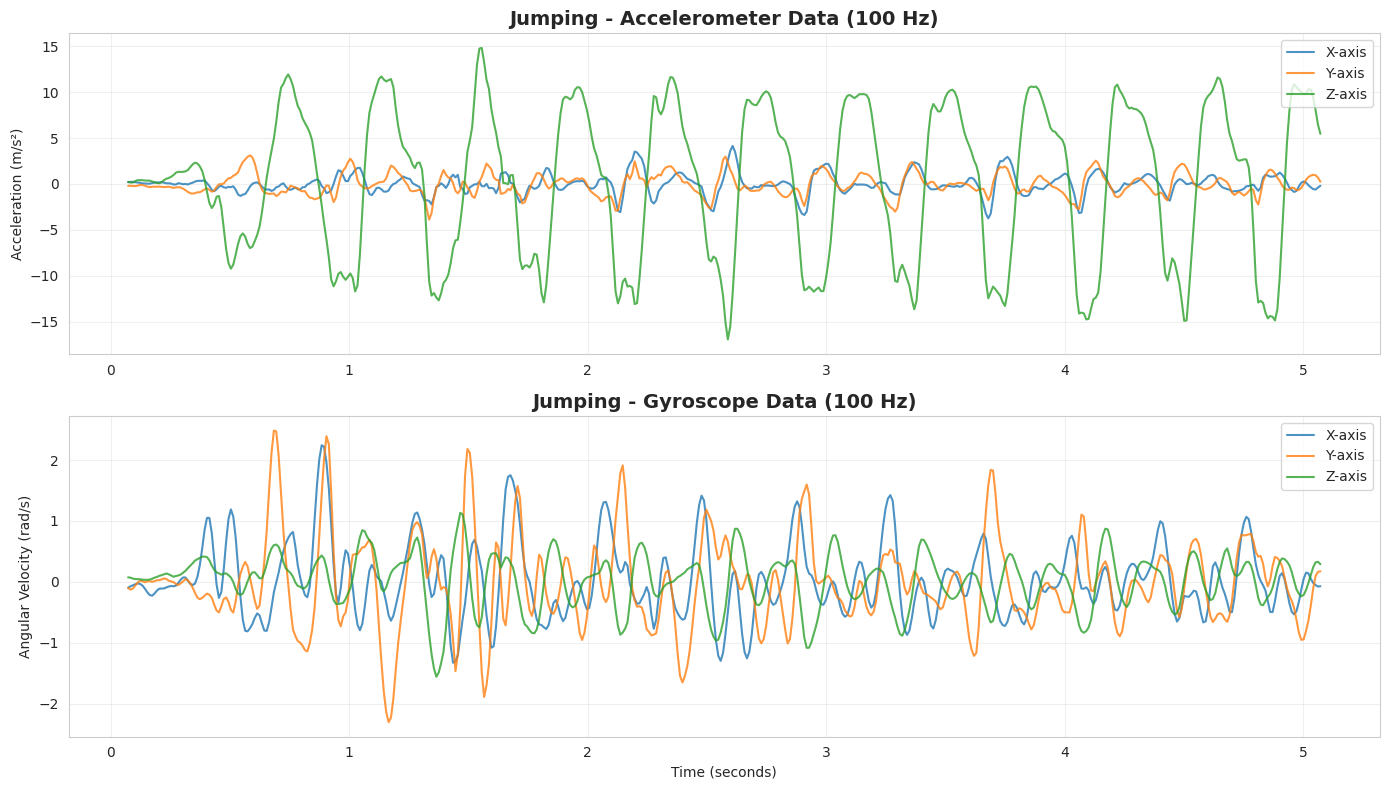

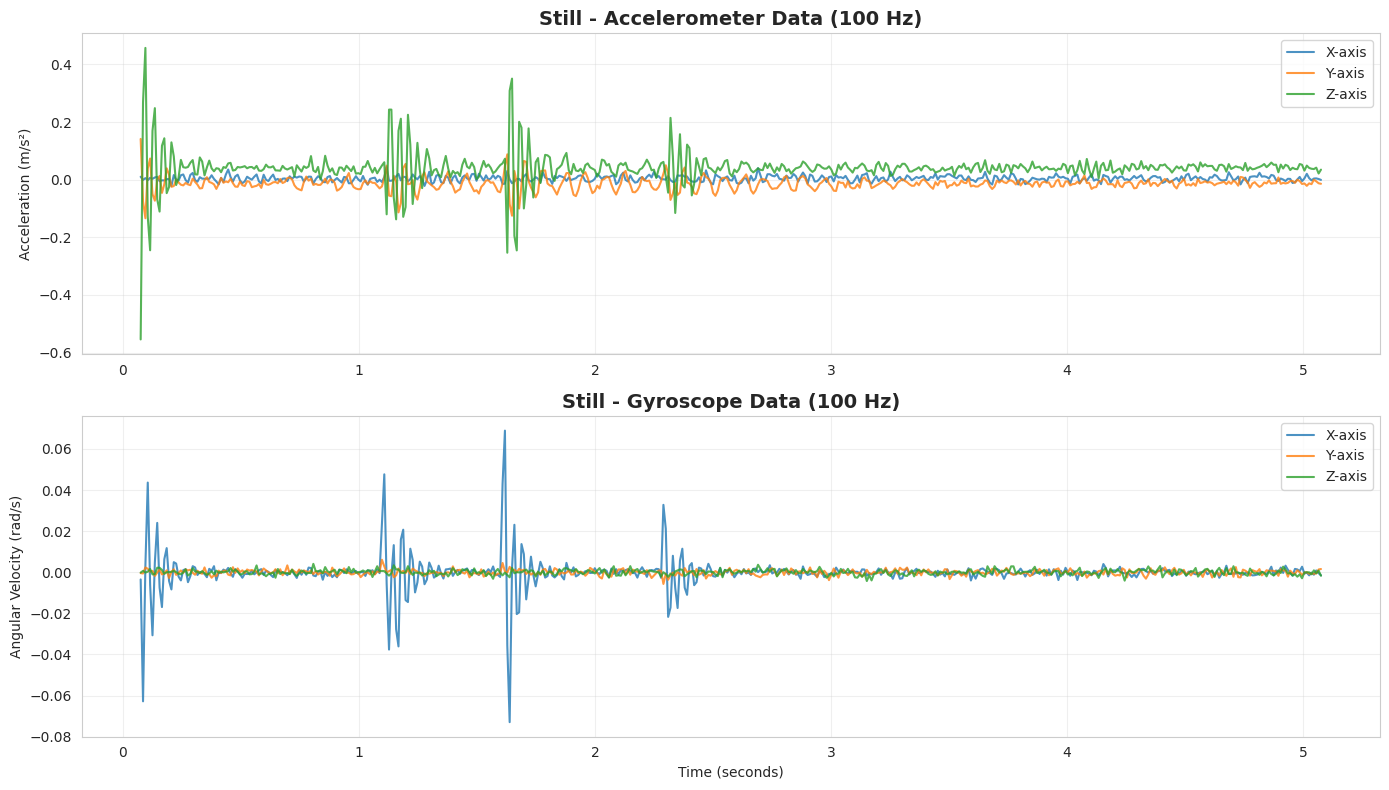

In [184]:
## plotting visualizations for accelerometer and gyroscope

def plot_activity_sensors(df, activity, max_samples=500):

    # Select a subset of the activity data
    sample = df[df['activity'] == activity].head(max_samples)

    fig, axes = plt.subplots(2, 1, figsize=(14,8))

    # Accelerometer plot
    axes[0].plot(sample['seconds_elapsed'], sample['x_acc'], label='X-axis', alpha=0.8, lw=1.5)
    axes[0].plot(sample['seconds_elapsed'], sample['y_acc'], label='Y-axis', alpha=0.8, lw=1.5)
    axes[0].plot(sample['seconds_elapsed'], sample['z_acc'], label='Z-axis', alpha=0.8, lw=1.5)

    axes[0].set_title(f"{activity.capitalize()} - Accelerometer Data (100 Hz)", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Acceleration (m/s²)")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)

    # Gyroscope plot
    axes[1].plot(sample['seconds_elapsed'], sample['x_gyro'], label='X-axis', alpha=0.8, lw=1.5)
    axes[1].plot(sample['seconds_elapsed'], sample['y_gyro'], label='Y-axis', alpha=0.8, lw=1.5)
    axes[1].plot(sample['seconds_elapsed'], sample['z_gyro'], label='Z-axis', alpha=0.8, lw=1.5)

    axes[1].set_title(f"{activity.capitalize()} - Gyroscope Data (100 Hz)", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Time (seconds)")
    axes[1].set_ylabel("Angular Velocity (rad/s)")
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()

    # Save visualization
    plt.savefig(f'visualization_{activity}.png', dpi=300, bbox_inches='tight')

    plt.show()


# Loop through all activities in dataset
activities = complete_dataset['activity'].unique()

for activity in activities:
    plot_activity_sensors(complete_dataset, activity)

## Feature Engineering for Human Activity Recognition

Raw accelerometer and gyroscope signals cannot be used directly by most machine learning models because individual sensor readings do not represent meaningful activities. Instead, we extract statistical and signal-processing features from short segments of sensor data using sliding windows.

Each window represents a short time interval of motion, and several types of features are extracted to describe the characteristics of the signal.

### Time-Domain Features
These features describe statistical properties of the signal within a window:
- Mean
- Standard deviation
- Minimum
- Maximum
- Root Mean Square (RMS)

These measures capture the overall level and variability of motion.

### Magnitude Features
Accelerometer and gyroscope axes are combined to compute signal magnitude:

\[
\sqrt{x^2 + y^2 + z^2}
\]

Magnitude features represent the **overall movement intensity** independent of device orientation.

### Frequency-Domain Features
Human activities often exhibit periodic motion patterns (e.g., walking). To capture these patterns, we apply the Fast Fourier Transform (FFT) to each signal and extract:
- Spectral energy
- Dominant frequency
- Spectral entropy

These features help identify rhythmic activities such as walking and jumping.

Combining **time-domain, magnitude, and frequency-domain features** creates a richer representation of human motion and significantly improves the performance of activity recognition models.

In [185]:
# Best-practice HAR feature extraction
def extract_features(df, sampling_rate=100):

    features = {}

    acc_cols = ['x_acc','y_acc','z_acc']
    gyro_cols = ['x_gyro','y_gyro','z_gyro']
    sensor_cols = acc_cols + gyro_cols

    # ----------------------------
    # Time-domain features
    # ----------------------------
    for col in sensor_cols:

        signal = df[col].values

        features[f'{col}_mean'] = np.mean(signal)
        features[f'{col}_std'] = np.std(signal)
        features[f'{col}_min'] = np.min(signal)
        features[f'{col}_max'] = np.max(signal)

        # Root Mean Square
        features[f'{col}_rms'] = np.sqrt(np.mean(signal**2))


    # ----------------------------
    # Magnitude features
    # ----------------------------
    acc_mag = np.sqrt(df['x_acc']**2 + df['y_acc']**2 + df['z_acc']**2)
    gyro_mag = np.sqrt(df['x_gyro']**2 + df['y_gyro']**2 + df['z_gyro']**2)

    features['acc_mag_mean'] = acc_mag.mean()
    features['acc_mag_std'] = acc_mag.std()

    features['gyro_mag_mean'] = gyro_mag.mean()
    features['gyro_mag_std'] = gyro_mag.std()


    # ----------------------------
    # Frequency-domain features
    # ----------------------------
    for col in sensor_cols:

        signal = df[col].values

        fft_vals = np.abs(fft(signal))
        freqs = np.fft.fftfreq(len(signal), d=1/sampling_rate)

        positive_freqs = freqs[freqs >= 0]
        positive_fft = fft_vals[freqs >= 0]

        # Spectral energy
        features[f'{col}_fft_energy'] = np.sum(positive_fft**2)

        # Dominant frequency
        features[f'{col}_dominant_freq'] = positive_freqs[np.argmax(positive_fft)]

        # Spectral entropy
        power = positive_fft**2
        power_norm = power / np.sum(power)
        spectral_entropy = -np.sum(power_norm * np.log2(power_norm + 1e-12))

        features[f'{col}_spectral_entropy'] = spectral_entropy


    return features

## Segment Data into Time Windows
Human activity recognition typically uses sliding windows because activities occur over short time intervals.

This block:

Splits recordings into windows of 100 samples

Uses 50 sample overlap

Extracts features from each window

Creates a feature dataset for machine learning

Each window becomes one training example.


In [186]:
WINDOW_SIZE = 100
STEP_SIZE = 50

feature_rows = []

for recording_id, recording_df in complete_dataset.groupby('recording_id'):

    recording_df = recording_df.sort_values('seconds_elapsed')

    for start in range(0, len(recording_df) - WINDOW_SIZE, STEP_SIZE):

        window = recording_df.iloc[start:start+WINDOW_SIZE]

        feats = extract_features(window)

        feats['activity'] = window['activity'].iloc[0]
        feats['participant'] = window['participant'].iloc[0]
        feats['recording_id'] = recording_id

        feature_rows.append(feats)

# Convert to dataframe
features_df = pd.DataFrame(feature_rows)

# ------------------------------
# Reporting information
# ------------------------------

print(f"Extracted {len(features_df)} feature windows")
print(f"Complete feature set: {features_df.shape}")

print("\nSamples per activity:")

activity_counts = features_df['activity'].value_counts()

for activity, count in activity_counts.items():
    print(f"{activity:<12}: {count:>4} windows")

# ------------------------------
# Save dataset
# ------------------------------

features_df.to_csv("Complete_Features.csv", index=False)

print("\nSaved: Complete_Features.csv")

features_df.head()

Extracted 162 feature windows
Complete feature set: (162, 55)

Samples per activity:
still       :   42 windows
jumping     :   40 windows
standing    :   40 windows
walking     :   40 windows

Saved: Complete_Features.csv


,x_acc_mean,x_acc_std,x_acc_min,x_acc_max,x_acc_rms,y_acc_mean,y_acc_std,y_acc_min,y_acc_max,y_acc_rms,...,x_gyro_spectral_entropy,y_gyro_fft_energy,y_gyro_dominant_freq,y_gyro_spectral_entropy,z_gyro_fft_energy,z_gyro_dominant_freq,z_gyro_spectral_entropy,activity,participant,recording_id
0,-0.024316,0.594218,-1.306401,1.759535,0.594715,-0.116502,1.133348,-1.968466,3.115746,1.139320,...,3.176379,3150.409850,5.0,3.156225,491.264404,0.0,2.875940,jumping,Dennis,Dennis_jumping_recording_01
1,-0.133448,0.760785,-2.222694,1.759535,0.772401,-0.126782,1.292998,-3.881598,3.115746,1.299199,...,3.177632,6149.500896,5.0,2.811461,1552.286694,5.0,2.566027,jumping,Dennis,Dennis_jumping_recording_01
2,-0.189592,0.789213,-2.222694,1.740416,0.811666,-0.127670,1.091509,-3.881598,2.222267,1.098950,...,3.123246,4198.070285,5.0,3.251104,1677.427228,5.0,2.281697,jumping,Dennis,Dennis_jumping_recording_01
3,-0.033165,1.304900,-3.067777,3.532609,1.305321,-0.052298,1.228745,-2.915850,2.646325,1.229857,...,2.801055,2995.791311,5.0,3.523538,1028.189430,5.0,2.192168,jumping,Dennis,Dennis_jumping_recording_01
4,0.126082,1.648921,-3.378743,4.139162,1.653734,-0.022183,1.283025,-2.915850,2.976243,1.283217,...,3.369746,2963.160749,5.0,3.005732,1250.327091,5.0,1.773630,jumping,Dennis,Dennis_jumping_recording_01


## Normalization

In [187]:
from sklearn.preprocessing import StandardScaler

# Separate features and metadata
feature_cols = features_df.drop(columns=['activity','participant','recording_id']).columns

scaler = StandardScaler()

features_df[feature_cols] = scaler.fit_transform(features_df[feature_cols])

print("Feature normalization complete.")
features_df.head()

Feature normalization complete.


,x_acc_mean,x_acc_std,x_acc_min,x_acc_max,x_acc_rms,y_acc_mean,y_acc_std,y_acc_min,y_acc_max,y_acc_rms,...,x_gyro_spectral_entropy,y_gyro_fft_energy,y_gyro_dominant_freq,y_gyro_spectral_entropy,z_gyro_fft_energy,z_gyro_dominant_freq,z_gyro_spectral_entropy,activity,participant,recording_id
0,-0.301657,0.210263,-0.063537,0.631506,0.194215,-0.420661,0.898019,-0.486473,1.210662,0.878432,...,-0.117841,1.776862,-0.381272,-0.517985,0.079401,-0.628618,-0.370299,jumping,Dennis,Dennis_jumping_recording_01
1,-1.346916,0.505733,-0.649058,0.631506,0.508352,-0.496066,1.141722,-1.736255,1.210662,1.121083,...,-0.116654,4.010426,-0.381272,-0.896256,1.394009,-0.174803,-0.650397,jumping,Dennis,Dennis_jumping_recording_01
2,-1.884655,0.556159,-0.649058,0.615328,0.577770,-0.502578,0.834152,-1.736255,0.645416,0.817161,...,-0.168165,2.557104,-0.381272,-0.413886,1.549058,-0.174803,-0.907373,jumping,Dennis,Dennis_jumping_recording_01
3,-0.386409,1.470922,-1.189076,2.131788,1.450520,0.050271,1.043640,-1.105366,0.913690,1.015841,...,-0.473324,1.661710,-0.381272,-0.114975,0.744652,-0.174803,-0.988288,jumping,Dennis,Dennis_jumping_recording_01
4,1.138841,2.081170,-1.387786,2.645022,2.066491,0.271165,1.126498,-1.105366,1.122407,1.096826,...,0.065304,1.637409,-0.381272,-0.683104,1.019880,-0.174803,-1.366561,jumping,Dennis,Dennis_jumping_recording_01


## Train/Test Split

In [188]:
from sklearn.model_selection import train_test_split

# Separate features and labels
X = features_df.drop(columns=['activity','participant','recording_id'])
y = features_df['activity']

# Train-test split (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

print("\nTrain distribution:")

train_counts = y_train.value_counts()

for activity, count in train_counts.items():
    print(f"   {activity:<10}: {count} samples")

Training set: 129 samples
Test set: 33 samples

Train distribution:
   still     : 33 samples
   standing  : 32 samples
   walking   : 32 samples
   jumping   : 32 samples


## Preparing Observation Sequences for Hidden Markov Model

Hidden Markov Models operate on sequences of observations rather than independent samples.  
In this project, each recording represents a continuous time-series of human motion.

To train the HMM, we therefore organize the feature vectors into **ordered sequences**, where each sequence corresponds to a single recording.

Two components are required:

- **X** – the concatenated feature vectors from all sequences
- **sequence_lengths** – the number of observations in each sequence

The sequence lengths allow the HMM to correctly separate the combined feature matrix into individual recordings during training.

In [189]:
# Rebuild sequential training data for HMM

feature_cols = features_df.drop(columns=['activity','participant','recording_id']).columns

# Create train_df from features_df using the training indices
train_df = features_df.loc[X_train.index]

train_sequences = []

for rec_id, group in train_df.groupby('recording_id'):

    group = group.sort_index()
    seq = group[feature_cols].values

    train_sequences.append(seq)

# concatenate sequences
X_seq = np.vstack(train_sequences)

print("Sequential dataset shape:", X_seq.shape)

Sequential dataset shape: (129, 52)


## HMM Implementation

## Gaussian Hidden Markov Model with Gaussian Emissions

To model temporal patterns in human activity data, we implement a Hidden Markov Model (HMM) with Gaussian emission probabilities.

In this model:

- **Hidden states** represent latent motion dynamics within an activity
- **Observations** are the feature vectors extracted from each sliding window
- **Transition probabilities** model how hidden states evolve over time
- **Emission probabilities** model the likelihood of observing a feature vector given a hidden state

The Viterbi algorithm is used to compute the most likely sequence of hidden states and the log-likelihood of the observation sequence.

For activity recognition, we train **one HMM per activity class**, and during prediction the activity whose HMM produces the **highest likelihood** for a sequence is selected.

In [190]:
# Gaussian Hidden Markov Model implementation

class GaussianHMM:

    def __init__(self, n_states, n_features):
        self.n_states = n_states
        self.n_features = n_features

        # Initialize parameters
        self.startprob_ = np.ones(n_states) / n_states
        self.transmat_ = np.ones((n_states, n_states)) / n_states

        self.means_ = np.random.randn(n_states, n_features) * 0.1
        self.covars_ = np.array([np.eye(n_features) for _ in range(n_states)])


    # Multivariate Gaussian probability
    def _gaussian_prob(self, x, mean, covar):

        n = len(mean)
        diff = x - mean

        covar_reg = covar + np.eye(n) * 1e-6

        try:
            covar_inv = np.linalg.inv(covar_reg)
            det = np.linalg.det(covar_reg)
        except:
            return 1e-10

        if det <= 0:
            return 1e-10

        norm = 1.0 / np.sqrt((2*np.pi)**n * det)
        exponent = -0.5 * np.dot(np.dot(diff, covar_inv), diff)

        return max(norm * np.exp(exponent), 1e-10)


    # Compute emission probabilities
    def _compute_emission_prob(self, X):

        n_samples = len(X)
        emission_prob = np.zeros((n_samples, self.n_states))

        for t in range(n_samples):
            for s in range(self.n_states):
                emission_prob[t, s] = self._gaussian_prob(
                    X[t],
                    self.means_[s],
                    self.covars_[s]
                )

        return emission_prob


    # Viterbi decoding
    def viterbi(self, X):

        n_samples = len(X)
        emission_prob = self._compute_emission_prob(X)

        viterbi_prob = np.zeros((n_samples, self.n_states))
        viterbi_path = np.zeros((n_samples, self.n_states), dtype=int)

        viterbi_prob[0] = np.log(self.startprob_ + 1e-10) + np.log(emission_prob[0] + 1e-10)

        for t in range(1, n_samples):
            for j in range(self.n_states):

                trans_prob = viterbi_prob[t-1] + np.log(self.transmat_[:, j] + 1e-10)

                viterbi_path[t, j] = np.argmax(trans_prob)
                viterbi_prob[t, j] = np.max(trans_prob) + np.log(emission_prob[t, j] + 1e-10)

        states = np.zeros(n_samples, dtype=int)
        states[-1] = np.argmax(viterbi_prob[-1])

        for t in range(n_samples-2, -1, -1):
            states[t] = viterbi_path[t+1, states[t+1]]

        return states, np.max(viterbi_prob[-1])


    # Simple parameter initialization using data
    def fit(self, X):

        # Initialize means using random samples
        idx = np.random.choice(len(X), self.n_states)
        self.means_ = X[idx]

        # Initialize covariances
        cov = np.cov(X.T)
        self.covars_ = np.array([cov for _ in range(self.n_states)])

        return self

## Baum-welch Training

## Baum–Welch Algorithm for HMM Training

To estimate the parameters of the Hidden Markov Model, we apply the **Baum–Welch algorithm**, which is an Expectation–Maximization (EM) procedure.

The algorithm iteratively improves model parameters by:

**E-Step**
- Forward algorithm computes observation probabilities.
- Backward algorithm computes future state probabilities.
- These are combined to estimate hidden state probabilities.

**M-Step**
- Update initial state probabilities.
- Update transition probabilities.
- Update Gaussian emission parameters (means and covariances).

Training continues until the log-likelihood converges or the maximum number of iterations is reached.

In [191]:
def baum_welch_sequences(model, sequences, max_iter=100, tol=1e-6, verbose=True):

    n_states = model.n_states
    log_likelihoods = []

    for iteration in range(max_iter):

        total_ll = 0

        # accumulators
        gamma_sum = np.zeros(n_states)
        xi_sum = np.zeros((n_states, n_states))
        mean_num = np.zeros((n_states, model.n_features))
        cov_num = np.zeros((n_states, model.n_features, model.n_features))

        for X in sequences:

            n_samples = len(X)

            emission_prob = model._compute_emission_prob(X)

            # ----- Forward -----
            alpha = np.zeros((n_samples, n_states))
            scale = np.zeros(n_samples)

            alpha[0] = model.startprob_ * emission_prob[0]
            scale[0] = np.sum(alpha[0])
            alpha[0] /= scale[0]

            for t in range(1, n_samples):
                alpha[t] = emission_prob[t] * np.dot(alpha[t-1], model.transmat_)
                scale[t] = np.sum(alpha[t])
                alpha[t] /= scale[t]

            # ----- Backward -----
            beta = np.zeros((n_samples, n_states))
            beta[-1] = 1.0

            for t in range(n_samples-2, -1, -1):
                beta[t] = np.dot(model.transmat_, emission_prob[t+1] * beta[t+1])
                beta[t] /= scale[t+1]

            log_likelihood = np.sum(np.log(scale + 1e-10))
            total_ll += log_likelihood

            gamma = alpha * beta
            gamma /= np.sum(gamma, axis=1, keepdims=True)

            xi = np.zeros((n_samples-1, n_states, n_states))

            for t in range(n_samples-1):
                denom = np.sum(
                    alpha[t][:,None] *
                    model.transmat_ *
                    emission_prob[t+1] *
                    beta[t+1]
                )

                xi[t] = (
                    alpha[t][:,None] *
                    model.transmat_ *
                    emission_prob[t+1] *
                    beta[t+1]
                ) / (denom + 1e-10)

            gamma_sum += np.sum(gamma[:-1], axis=0)
            xi_sum += np.sum(xi, axis=0)

            for i in range(n_states):
                mean_num[i] += np.sum(gamma[:,i][:,None] * X, axis=0)

        log_likelihoods.append(total_ll)

        # ----- M STEP -----

        model.transmat_ = xi_sum / (gamma_sum[:,None] + 1e-10)

        for i in range(n_states):

            model.means_[i] = mean_num[i] / (np.sum(gamma_sum[i]) + 1e-10)

        # covariance update
        for X in sequences:

            n_samples = len(X)
            emission_prob = model._compute_emission_prob(X)

            alpha = np.zeros((n_samples, n_states))
            scale = np.zeros(n_samples)

            alpha[0] = model.startprob_ * emission_prob[0]
            scale[0] = np.sum(alpha[0])
            alpha[0] /= scale[0]

            for t in range(1, n_samples):
                alpha[t] = emission_prob[t] * np.dot(alpha[t-1], model.transmat_)
                scale[t] = np.sum(alpha[t])
                alpha[t] /= scale[t]

            beta = np.zeros((n_samples, n_states))
            beta[-1] = 1

            for t in range(n_samples-2, -1, -1):
                beta[t] = np.dot(model.transmat_, emission_prob[t+1] * beta[t+1])
                beta[t] /= scale[t+1]

            gamma = alpha * beta
            gamma /= np.sum(gamma, axis=1, keepdims=True)

            for i in range(n_states):

                diff = X - model.means_[i]

                cov_num[i] += (
                    (gamma[:,i][:,None] * diff).T @ diff
                )

        for i in range(n_states):
            model.covars_[i] = (
                cov_num[i] / (gamma_sum[i] + 1e-10)
            ) + np.eye(model.n_features) * 1e-6

        if verbose:
            print(f"Iteration {iteration}: LL = {total_ll:.4f}")

        if iteration > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            print(f"Converged at iteration {iteration}")
            break

    return model, log_likelihoods

## Training Model using BW

In [192]:
from sklearn.cluster import KMeans
n_states = 4
n_features = X_train.shape[1]

# Create a new HMM model
hmm_model = GaussianHMM(n_states, n_features)

# Fit K-Means to observation data
kmeans = KMeans(n_clusters=n_states, random_state=42)

labels = kmeans.fit_predict(X_seq)

# Initialize means from clusters
hmm_model.means_ = kmeans.cluster_centers_

# Initialize covariances from cluster spread
for i in range(n_states):

    cluster_data = X_seq[labels == i]

    if len(cluster_data) > 1:
        hmm_model.covars_[i] = (
            np.cov(cluster_data.T)
            + np.eye(n_features) * 0.01
        )

# Break transition symmetry so Baum-Welch can learn
hmm_model.transmat_ += np.random.rand(n_states, n_states) * 0.01
hmm_model.transmat_ /= hmm_model.transmat_.sum(axis=1, keepdims=True)

print("K-Means initialization completed")
print("Cluster sizes:", np.bincount(labels))
print("\nInitial transition matrix:")
print(np.round(hmm_model.transmat_, 3))

K-Means initialization completed
Cluster sizes: [64  7 25 33]

Initial transition matrix:
[[0.25  0.248 0.25  0.252]
 [0.253 0.247 0.249 0.251]
 [0.25  0.251 0.252 0.247]
 [0.249 0.253 0.251 0.248]]


## Plotting Convergence

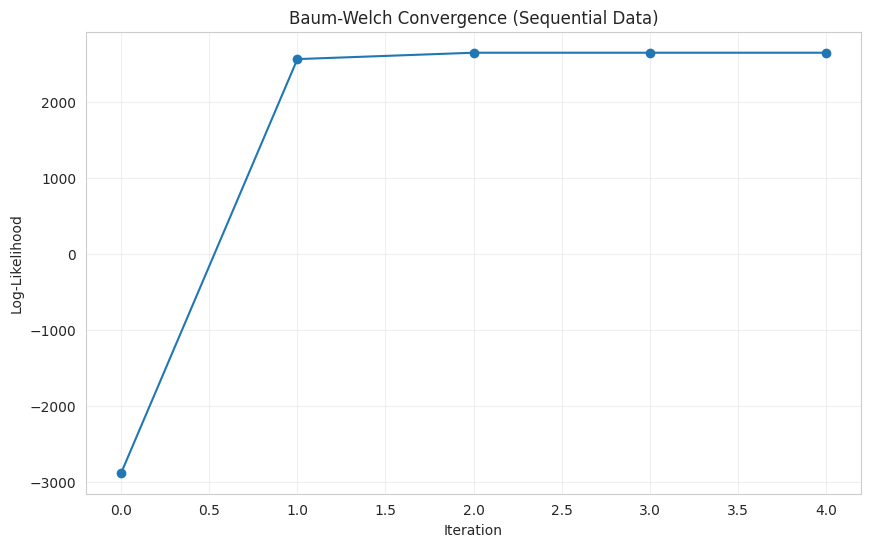

In [193]:
plt.figure(figsize=(10,6))

plt.plot(log_likelihoods, marker='o')

plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.title("Baum-Welch Convergence (Sequential Data)")

plt.grid(alpha=0.3)

plt.show()

In [194]:
print("Learned transition matrix:")
print(np.round(hmm_model.transmat_,3))

Learned transition matrix:
[[0.25  0.248 0.25  0.252]
 [0.253 0.247 0.249 0.251]
 [0.25  0.251 0.252 0.247]
 [0.249 0.253 0.251 0.248]]


## Visualize HMM Parameters

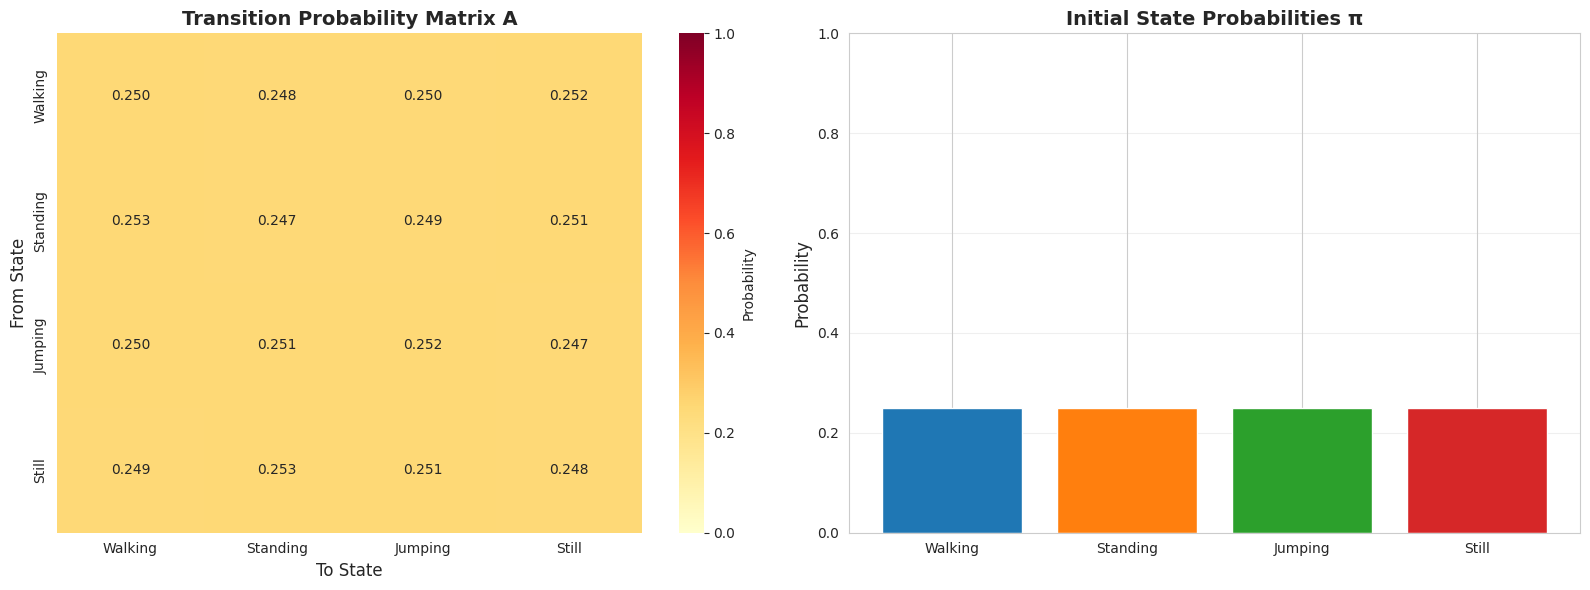


Transition Matrix Analysis:
   Diagonal values (self-transitions):
   Walking     : 0.250 (stay in same state)
   Standing    : 0.247 (stay in same state)
   Jumping     : 0.252 (stay in same state)
   Still       : 0.248 (stay in same state)


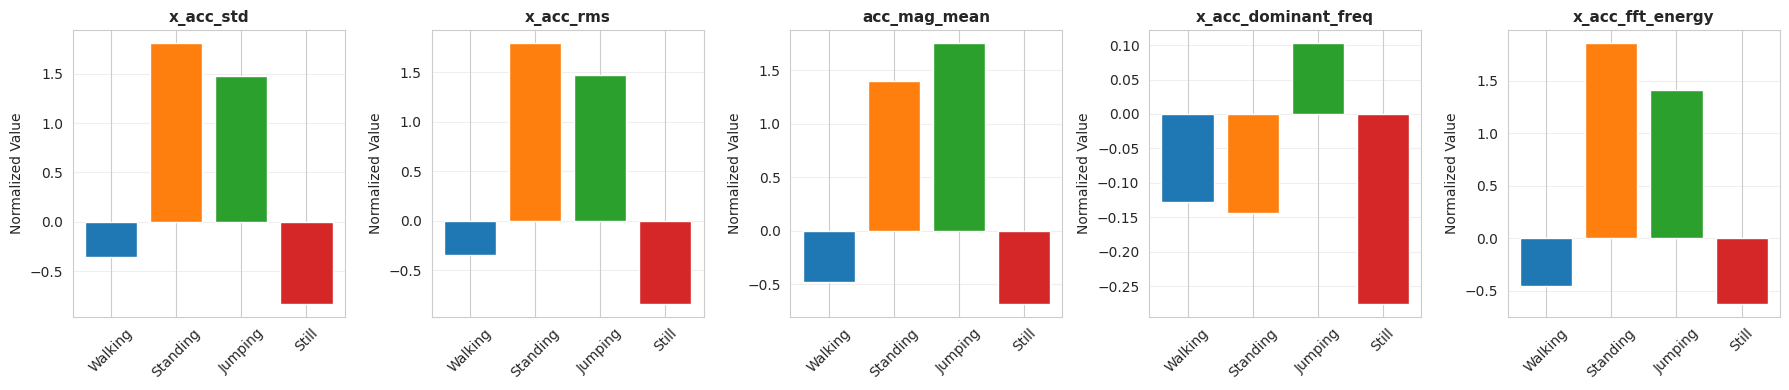

In [195]:
activity_labels = ['Walking', 'Standing', 'Jumping', 'Still']

# Transition Matrix Heatmap
fig, axes = plt.subplots(1, 2, figsize = (16, 6))

# Transition probabilities
sns.heatmap(hmm_model.transmat_, annot = True, fmt = '.3f', cmap = 'YlOrRd',
            xticklabels = activity_labels, yticklabels = activity_labels,
            cbar_kws={'label': 'Probability'}, ax = axes[0], vmin = 0, vmax = 1)
axes[0].set_title('Transition Probability Matrix A', fontsize = 14, fontweight = 'bold')
axes[0].set_ylabel('From State', fontsize = 12)
axes[0].set_xlabel('To State', fontsize = 12)

# Initial state probabilities
axes[1].bar(activity_labels, hmm_model.startprob_, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
axes[1].set_ylabel('Probability', fontsize = 12)
axes[1].set_title('Initial State Probabilities π', fontsize = 14, fontweight = 'bold')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha = 0.3, axis = 'y')

plt.tight_layout()
plt.savefig('transition_emission_probs.png', dpi = 300, bbox_inches = 'tight')
plt.show()

print("\nTransition Matrix Analysis:")
print("   Diagonal values (self-transitions):")
for i, activity in enumerate(activity_labels):
    print(f"   {activity:<12}: {hmm_model.transmat_[i, i]:.3f} (stay in same state)")

# Visualize emission means for key features
feature_names = list(X_train.columns)
# Corrected feature names to match existing columns in X_train
key_features = ['x_acc_std', 'x_acc_rms', 'acc_mag_mean', 'x_acc_dominant_freq', 'x_acc_fft_energy']
feature_indices = [feature_names.index(f) for f in key_features if f in feature_names]

fig, axes = plt.subplots(1, len(feature_indices), figsize = (18, 4))
for idx, feat_idx in enumerate(feature_indices):
    feat_name = feature_names[feat_idx]
    axes[idx].bar(activity_labels, hmm_model.means_[:, feat_idx],
                  color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
    axes[idx].set_title(feat_name, fontsize = 11, fontweight = 'bold')
    axes[idx].tick_params(axis = 'x', rotation = 45)
    axes[idx].grid(True, alpha = 0.3, axis = 'y')
    axes[idx].set_ylabel('Normalized Value', fontsize = 10)

plt.tight_layout()
plt.savefig('emission_means_visualization.png', dpi = 300, bbox_inches = 'tight')
plt.show()

State → Activity Mapping:
State 0 → standing
State 1 → jumping
State 2 → jumping
State 3 → still

Overall Accuracy: 0.6970 (69.70%)


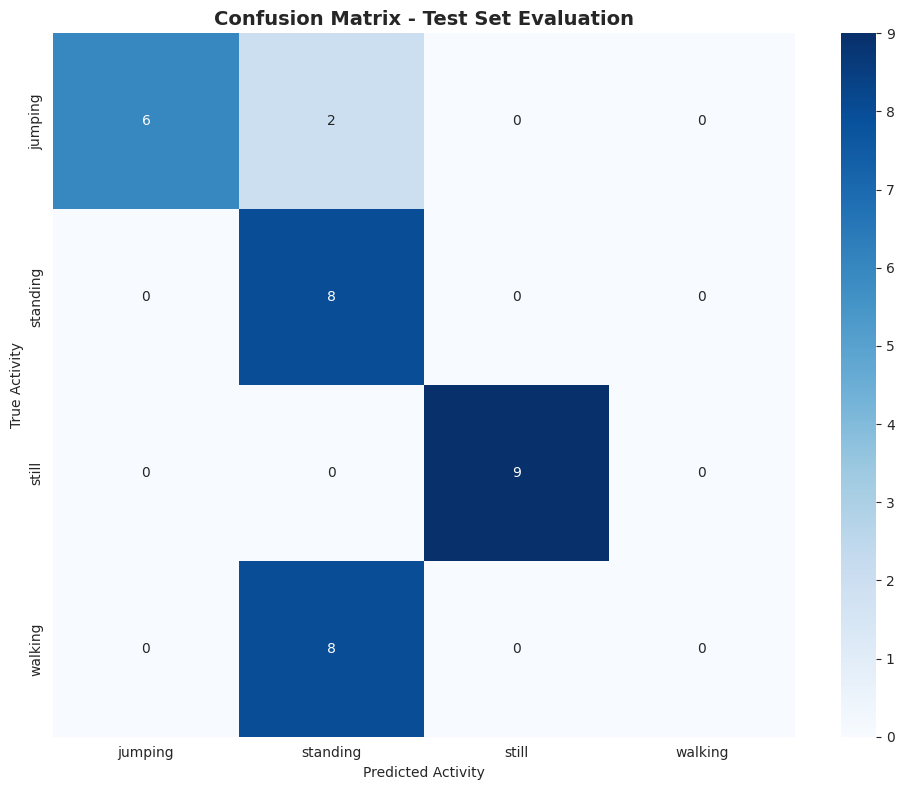


Classification Report

              precision    recall  f1-score   support

     jumping     1.0000    0.7500    0.8571         8
    standing     0.4444    1.0000    0.6154         8
       still     1.0000    1.0000    1.0000         9
     walking     0.0000    0.0000    0.0000         8

    accuracy                         0.6970        33
   macro avg     0.6111    0.6875    0.6181        33
weighted avg     0.6229    0.6970    0.6297        33



In [196]:
train_states, _ = hmm_model.viterbi(X_train.values)

state_activity_map = {}

for state in range(hmm_model.n_states):

    indices = np.where(train_states == state)[0]

    if len(indices) == 0:
        continue

    majority_activity = y_train.iloc[indices].mode()[0]

    state_activity_map[state] = majority_activity

print("State → Activity Mapping:")
for k, v in state_activity_map.items():
    print(f"State {k} → {v}")

test_states, _ = hmm_model.viterbi(X_test.values)

# Convert hidden states → activity predictions
y_pred = [state_activity_map.get(s, "Unknown") for s in test_states]

accuracy = accuracy_score(y_test, y_pred)

print(f"\nOverall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

activity_labels = sorted(y_test.unique())

conf_matrix = confusion_matrix(y_test, y_pred, labels=activity_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=activity_labels,
    yticklabels=activity_labels
)

plt.title("Confusion Matrix - Test Set Evaluation", fontsize=14, fontweight='bold')
plt.ylabel("True Activity")
plt.xlabel("Predicted Activity")

plt.tight_layout()
plt.show()


print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=activity_labels,
        digits=4
    )
)

In [200]:
def visualize_hidden_states_signal(hmm_model, raw_data_df, features_data_df, recording_id, feature_cols):

    # Select original raw signal data for plotting
    raw_signal_recording = raw_data_df[raw_data_df["recording_id"] == recording_id]
    raw_signal_recording = raw_signal_recording.sort_values("seconds_elapsed")

    # Select feature data for HMM decoding
    feature_recording = features_data_df[features_data_df["recording_id"] == recording_id]
    feature_recording = feature_recording.sort_values("recording_id") # Sorting by recording_id is fine here as features are derived sequentially

    # Extract sequence features for Viterbi decoding
    seq = feature_recording[feature_cols].values

    # Decode states
    states, _ = hmm_model.viterbi(seq)

    # Plot
    fig, axes = plt.subplots(2,1, figsize=(14,8), sharex=True)

    # Accelerometer signal
    axes[0].plot(raw_signal_recording["seconds_elapsed"], raw_signal_recording["x_acc"], label="x_acc")
    axes[0].plot(raw_signal_recording["seconds_elapsed"], raw_signal_recording["y_acc"], label="y_acc")
    axes[0].plot(raw_signal_recording["seconds_elapsed"], raw_signal_recording["z_acc"], label="z_acc")

    axes[0].set_title("Accelerometer Signal")
    axes[0].set_ylabel("Acceleration")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    time_stamps_for_states = raw_signal_recording["seconds_elapsed"].iloc[::STEP_SIZE].head(len(states)).values

    axes[1].step(
        time_stamps_for_states,
        states,
        where="post"
    )

    axes[1].set_title("Hidden States Learned by HMM")
    axes[1].set_ylabel("State")
    axes[1].set_xlabel("Time (seconds)")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

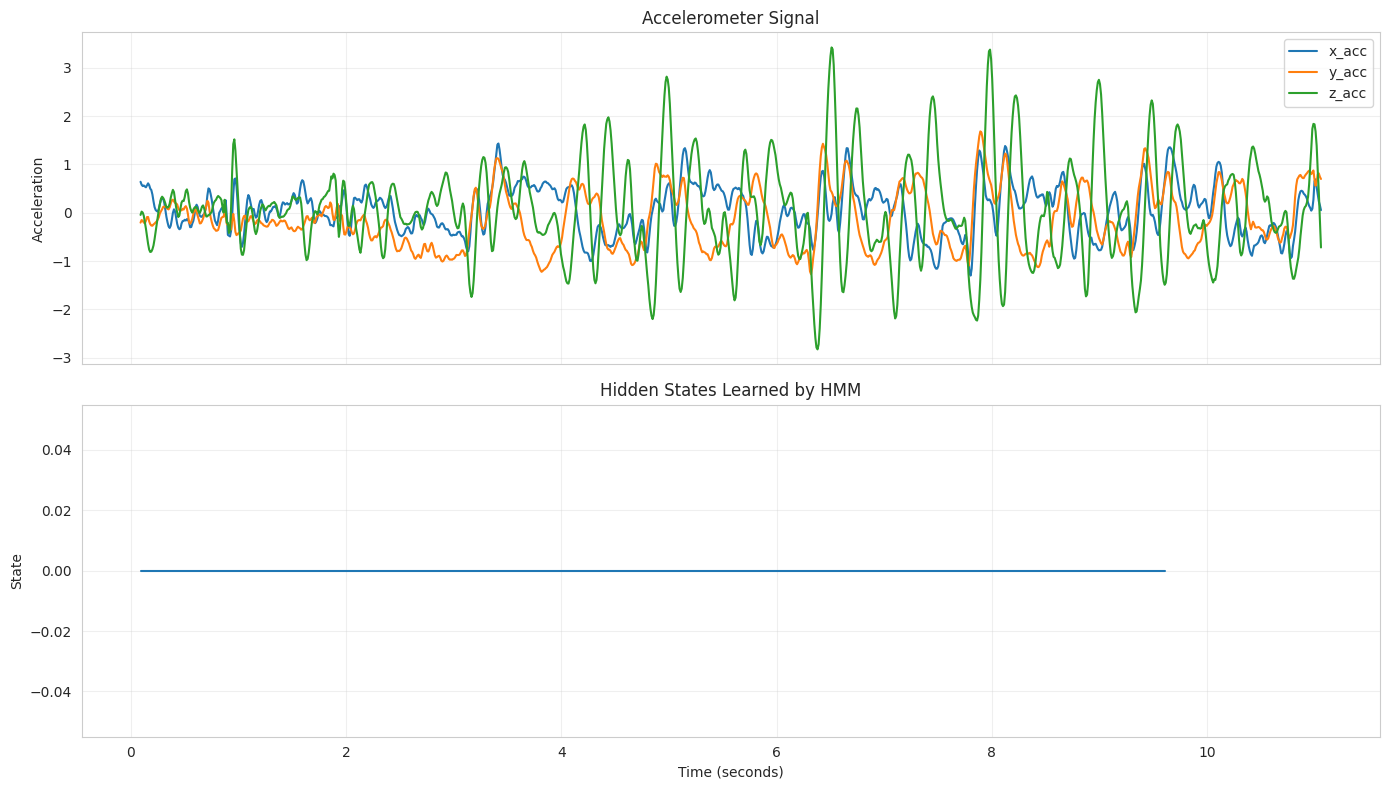

In [201]:
# Select an example recording
example_recording = complete_dataset["recording_id"].unique()[0]

visualize_hidden_states_signal(
    hmm_model,
    complete_dataset, # Pass raw data for plotting
    features_df,      # Pass features for HMM decoding
    example_recording,
    feature_cols
)

The hidden state visualization shows that the HMM converged to a single dominant state for this recording. This suggests that the extracted feature space did not contain sufficiently distinct temporal patterns for the model to segment the activity into multiple phases.This occured because my dataset is limited for an HMM which requires about 5000 - 50,000 windows.